# Global fire diagnostics
This notebook relies on and reads data from the notebook prepare_global_MODIS_fire_data.ipynb that prepares the global MODIS fire data, and needs to run after that notebook.

(The MODIS data updated the Giglio data used previously)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'

# Import the csv datasets:
# -----------------------
dataset = pd.read_csv('../../../Data-for-teaching-staff/Forest-fires/Global-fires/global-Jolly-etal-2015/Fig2a.csv'\
                      ,na_values='NaN',comment='%',skipinitialspace=True,skip_blank_lines=True,header=None)
data = np.asarray(dataset.iloc[:, :].values)
#header = dataset.iloc[:, :].columns
fire_season_length_years=data[:,0]
fire_season_length=data[:,1]

dataset = pd.read_csv('../../../Data-for-teaching-staff/Forest-fires/Global-fires/global-Jolly-etal-2015/Fig2b.csv'\
                      ,na_values='NaN',comment='%',skipinitialspace=True,skip_blank_lines=True,header=None)
data = np.asarray(dataset.iloc[:, :].values)
#header = dataset.iloc[:, :].columns
affected_area_years=data[:,0]
affected_area=data[:,1]

dataset = pd.read_csv('../../../Data-for-teaching-staff/Forest-fires/Global-fires/global-Jolly-etal-2015/Fig2c.csv'\
                      ,na_values='NaN',comment='%',skipinitialspace=True,skip_blank_lines=True,header=None)
data = np.asarray(dataset.iloc[:, :].values)
#header = dataset.iloc[:, :].columns
rain_free_days_length_years=data[:,0]
rain_free_days=data[:,1] 

# read MODIS global fire data"
global_fire_years=np.load("Output/to-pickle/global_fire_years.npy")
global_forest_fire_area=np.load("Output/to-pickle/global_forest_fire_area.npy")
global_savanna_fire_area=np.load("Output/to-pickle/global_savanna_fire_area.npy")
global_shrub_grass_fire_area=np.load("Output/to-pickle/global_shrub_grass_fire_area.npy")
global_crop_fire_area=np.load("Output/to-pickle/global_crop_fire_area.npy")
global_all_fire_area=np.load("Output/to-pickle/global_all_fire_area.npy")

# the following is replaced by MODIS data in a separate notebook:
# dataset = pd.read_csv('../../../Data-for-teaching-staff/Forest-fires/Giglio-etal-2013-global/global-area-burned-Giglio-etal.txt'\
#                       ,na_values='NaN',comment='#',skipinitialspace=False,skip_blank_lines=False,header=None)
# data = np.asarray(dataset.iloc[:, :].values)
# #header = dataset.iloc[:, :].columns
# global_fire_area_years=data[0,:]
# global_fire_area=data[1,:] 

print("done.")

done.


In [2]:
# Fit a regression line to the different time series:
# -----------------------------------------------------
# (a) 
x=1.0*fire_season_length_years; y=1.0*fire_season_length;
fit=linregress(x, y)
slope=fit.slope;
intercept=fit.intercept;
fire_season_length_fit=slope*fire_season_length_years+intercept
p=np.maximum(0.001,fit.pvalue);
r2=(fit.rvalue)**2
# show regression results in a box over the plots:
textstr_a = '\n'.join((
    r'$p<%.3f$' % (p, ),
    r'$r^2=%.2f$' % (r2, )))

# (b) 
x=1.0*affected_area_years; y=1.0*affected_area;
fit=linregress(x, y)
slope=fit.slope;
intercept=fit.intercept;
affected_area_fit=slope*affected_area_years+intercept
p=np.maximum(0.001,fit.pvalue);
r2=(fit.rvalue)**2
# show regression results in a box over the plots:
textstr_b = '\n'.join((
    r'$p<%.3f$' % (p, ),
    r'$r^2=%.2f$' % (r2, )))

# (c) 
x=1.0*global_fire_years.flatten(); y=1.0*global_all_fire_area.flatten();
fit=linregress(x, y)
slope=fit.slope;
intercept=fit.intercept;
global_fire_area_fit=slope*global_fire_years+intercept
p=np.maximum(0.001,fit.pvalue);
r2=(fit.rvalue)**2
# show regression results in a box over the plots:
textstr_c = '\n'.join((
    r'$p<%.3f$' % (p, ),
    r'$r^2=%.2f$' % (r2, )))

print("done.")

done.


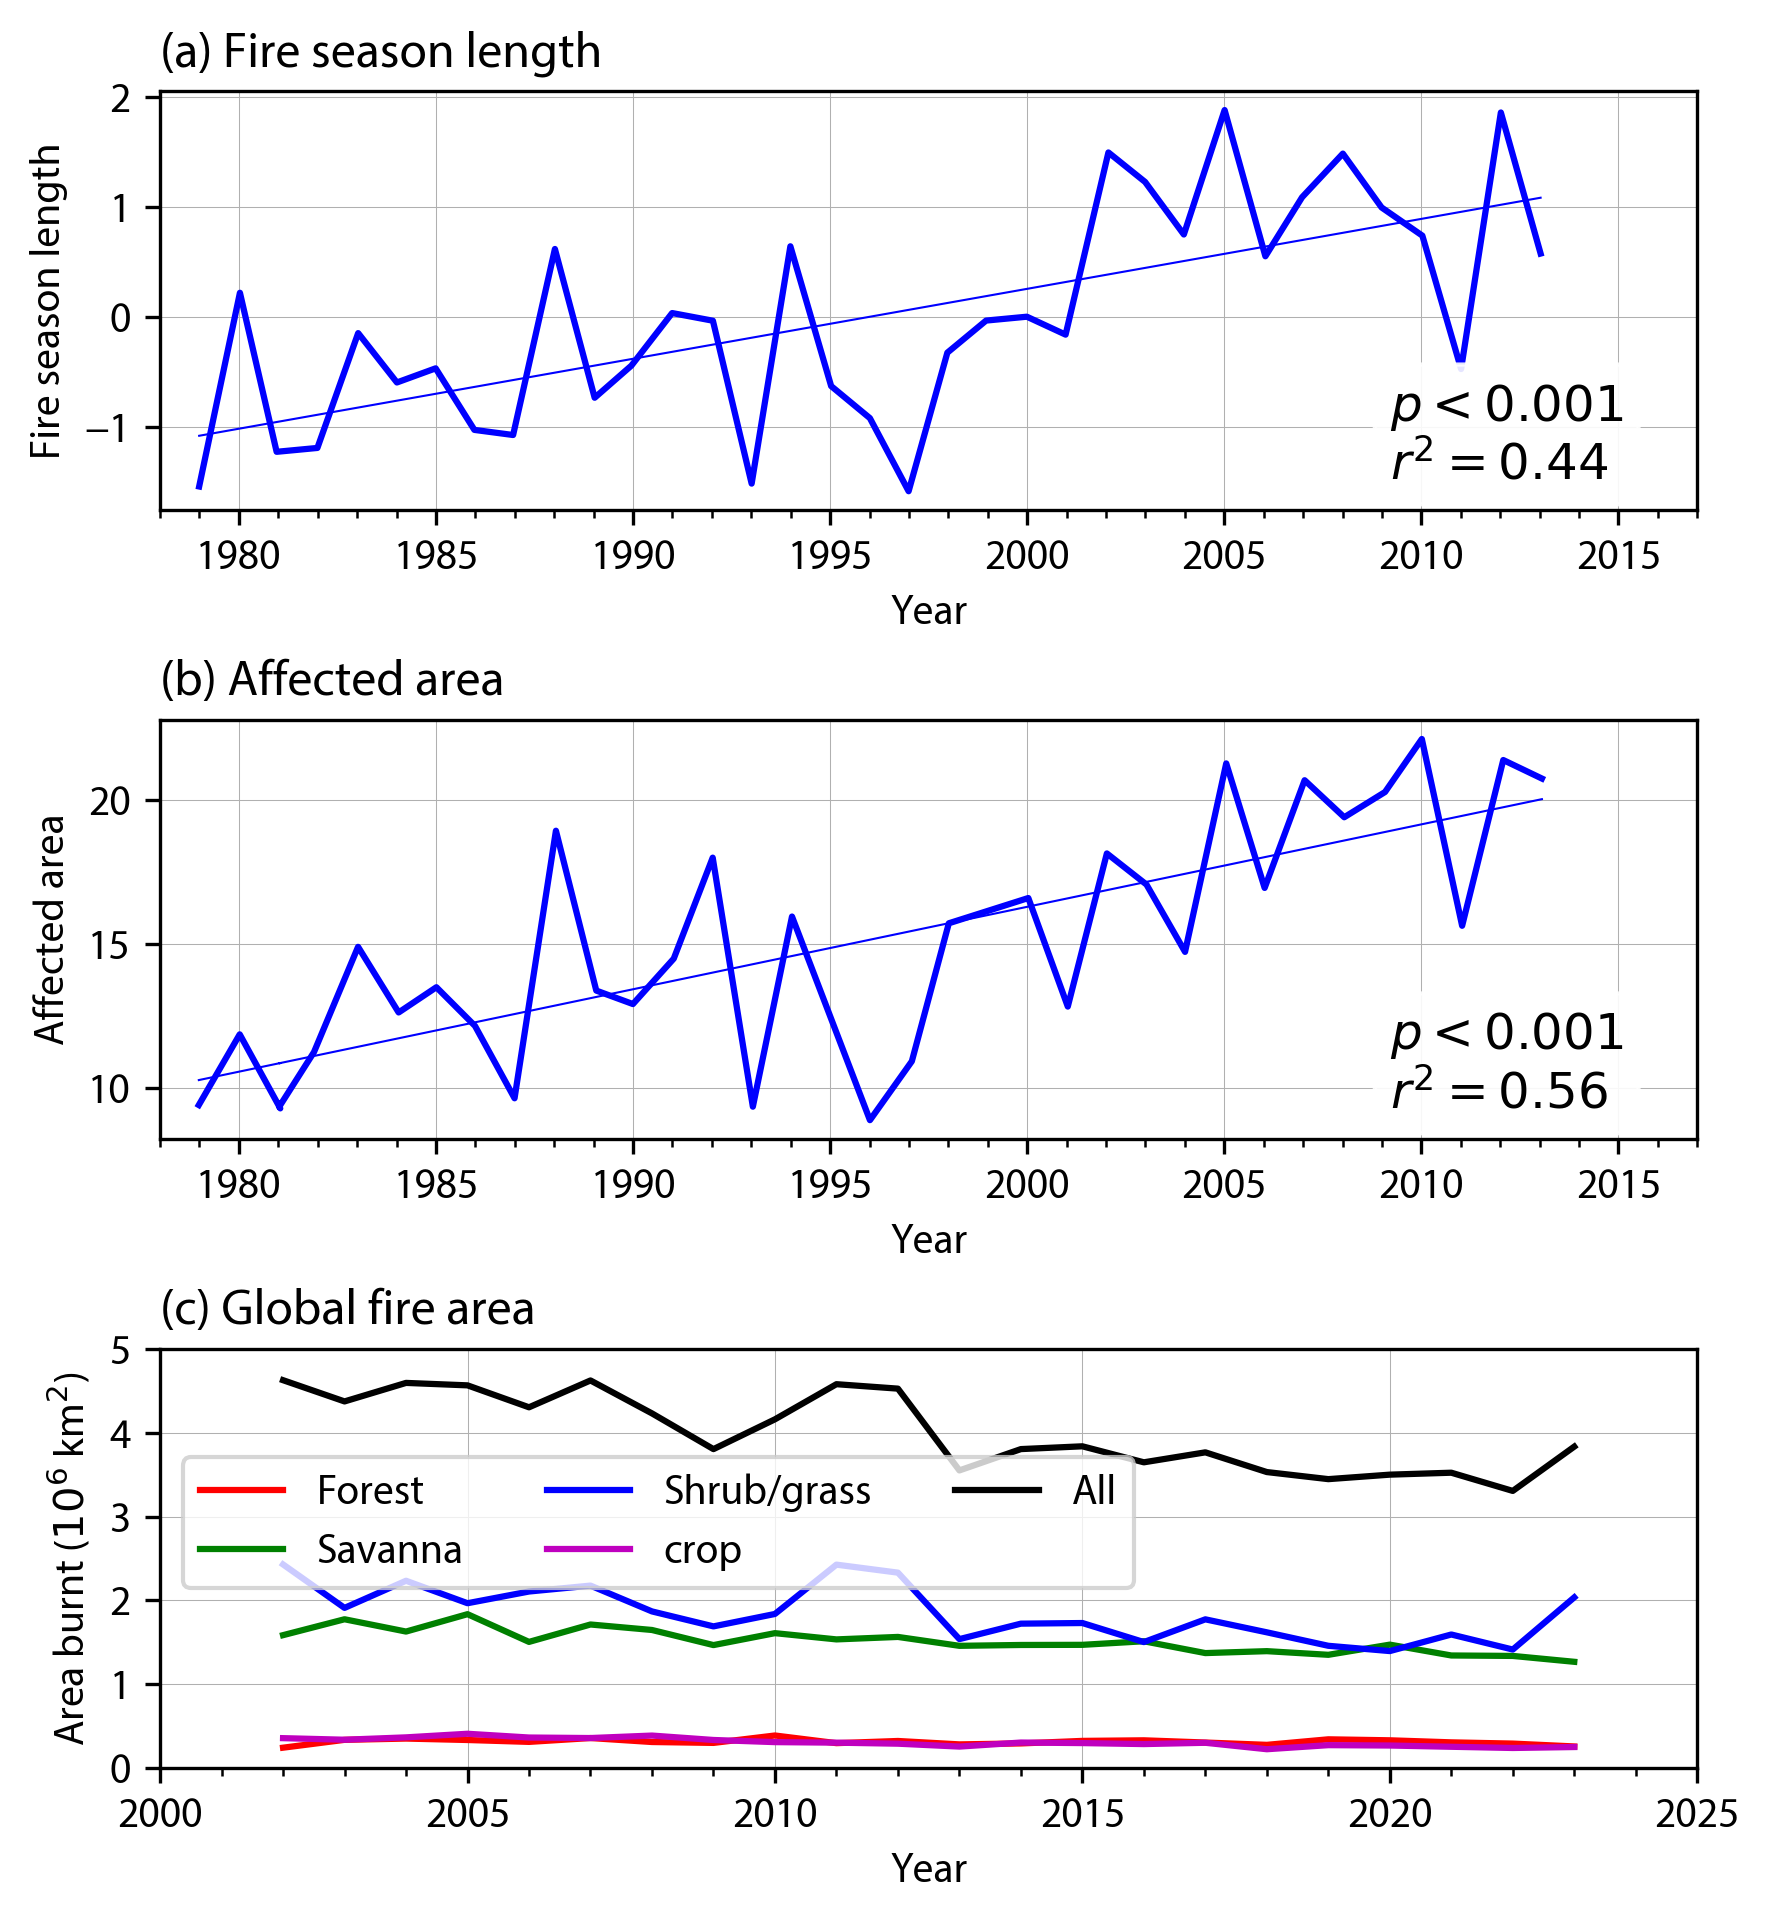

In [3]:
# plot
# for textboxes with (a), (b) etc:
props = dict(boxstyle='round', edgecolor="w", facecolor='w', alpha=0.9)

fig=plt.figure(figsize=(6,6.5),dpi=300)

plt.subplot(3,1,1)
plt.plot(fire_season_length_years,fire_season_length,'b')
plt.plot(fire_season_length_years,fire_season_length_fit,lw=0.5,color='b')
plt.xlabel("Year")
plt.gca().set_xticks(np.arange(1970,2020,1), minor=True)
plt.xlim(1978,2017)
plt.ylabel("Fire season length")
plt.grid(lw=0.25)
axes=plt.gca()
plt.title("(a) Fire season length",loc="left")
# plt.text(0.05, 0.95, "(a)", transform=axes.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props)
ax=plt.gca()
ax.text(0.8, 0.05, textstr_a, transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', bbox=props)


plt.subplot(3,1,2)
plt.plot(affected_area_years,affected_area,'b')
plt.plot(affected_area_years,affected_area_fit,lw=0.5,color='b')
plt.gca().set_xticks(np.arange(1970,2020,1), minor=True)
plt.xlim(1978,2017)
plt.xlabel("Year")
plt.ylabel("Affected area")
plt.grid(lw=0.25)
axes=plt.gca()
plt.title("(b) Affected area",loc="left")
# plt.text(0.05, 0.95, "(b)", transform=axes.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props)
ax=plt.gca()
ax.text(0.8, 0.05, textstr_b, transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', bbox=props)


plt.subplot(3,1,3)
plt.plot(global_fire_years,global_forest_fire_area/1.e6,'r',label="Forest")
plt.plot(global_fire_years,global_savanna_fire_area/1.e6,'g',label="Savanna")
plt.plot(global_fire_years,global_shrub_grass_fire_area/1.e6,'b',label="Shrub/grass")
plt.plot(global_fire_years,global_crop_fire_area/1.e6,'m',label="crop")
plt.plot(global_fire_years,global_all_fire_area/1.e6,'k',label="All")
plt.xlabel("Year")
plt.ylabel("Area burnt ($10^6$ km$^2$)")
plt.legend(ncol=3,loc=(0.015,0.43))
plt.grid(lw=0.25)
plt.gca().set_xticks(np.arange(2000,2030,1), minor=True)
plt.xlim(2000,2025)
plt.ylim(0,5)
axes=plt.gca()
plt.title("(c) Global fire area",loc="left")
#print(hlegend.get_window_extent())

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()
fig.savefig("Output/forest-fires-global-timeseries.pdf")